In [2]:
# Analiz veri setini yükleme

import pandas as pd
import matplotlib.pyplot as plt

veri = pd.read_csv("Analiz_Veri_Seti_Temiz.csv", sep=";", encoding="utf-8-sig")
veri.head()

,Tarih,TÜFE_Yıllık_Değişim,TÜFE_Aylık_Değişim,Politika_Faizi,Mevduat_Faizi,USDTRY,Gram_Altın,BIST100,Brent_Petrol,BIST_Gıda,BIST_Kimya,BIST_Ulaştırma,Tahvil_5Y_Faizi
0,2021-01-01,14.97,1.68,17.0,16.36,7.39,449.12,1473.45,55.04,2126.55,1920.05,1635.58,12.93
1,2021-02-01,15.61,0.91,17.0,16.22,7.07,413.65,1471.39,64.42,2004.86,2092.83,1845.28,13.48
2,2021-03-01,16.19,1.08,19.0,16.81,7.63,423.38,1391.73,62.74,1968.79,2111.92,1749.93,18.06
3,2021-04-01,17.14,1.68,19.0,17.78,8.16,464.33,1397.82,66.76,2023.13,2050.88,1688.19,17.87
4,2021-05-01,16.59,0.89,19.0,17.89,8.34,501.26,1420.49,68.95,1944.50,2032.19,1853.87,18.22


In [3]:
# Analiz setini sabitleme

veri["Tarih"] = pd.to_datetime(veri["Tarih"])
veri = veri.sort_values("Tarih").reset_index(drop=True)

analiz = veri.dropna().copy()

print("Ham veri boyutu:", veri.shape)
print("Analiz veri boyutu:", analiz.shape)

analiz.tail()

Ham veri boyutu: (62, 13)
Analiz veri boyutu: (62, 13)


,Tarih,TÜFE_Yıllık_Değişim,TÜFE_Aylık_Değişim,Politika_Faizi,Mevduat_Faizi,USDTRY,Gram_Altın,BIST100,Brent_Petrol,BIST_Gıda,BIST_Kimya,BIST_Ulaştırma,Tahvil_5Y_Faizi
57,2025-10-01,32.87,2.55,39.5,48.13,41.73,5744.17,10971.52,64.77,11914.43,13696.51,37054.70,33.41
58,2025-11-01,31.07,0.87,39.5,46.90,42.18,5764.62,10898.70,62.38,11549.91,13063.35,35096.32,32.47
59,2025-12-01,30.89,0.89,38.0,45.91,42.59,6030.79,11261.52,60.49,12458.20,12791.02,34500.04,30.91
60,2026-01-01,30.65,4.84,37.0,44.62,43.11,6817.67,13838.29,69.32,14702.67,15401.81,38746.53,30.23
61,2026-02-01,31.53,2.96,37.0,43.72,43.59,7515.92,13717.81,72.87,14457.32,14539.96,38111.92,30.98


In [4]:
# Temel özet

print("Tarih aralığı:")
print(analiz["Tarih"].min(), "->", analiz["Tarih"].max())

print("\nEksik değer kontrolü:")
print(analiz.isna().sum())

print("\nSayısal özet:")
display(analiz.describe().T)

Tarih aralığı:
2021-01-01 00:00:00 -> 2026-02-01 00:00:00

Eksik değer kontrolü:
Tarih                  0
TÜFE_Yıllık_Değişim    0
TÜFE_Aylık_Değişim     0
Politika_Faizi         0
Mevduat_Faizi          0
USDTRY                 0
Gram_Altın             0
BIST100                0
Brent_Petrol           0
BIST_Gıda              0
BIST_Kimya             0
BIST_Ulaştırma         0
Tahvil_5Y_Faizi        0
dtype: int64

Sayısal özet:


,count,mean,min,25%,50%,75%,max,std
Tarih,62,2023-07-17 08:07:44.516129024,2021-01-01 00:00:00,2022-04-08 12:00:00,2023-07-16 12:00:00,2024-10-24 06:00:00,2026-02-01 00:00:00,NaN
TÜFE_Yıllık_Değişim,62.0,47.467097,14.97,32.89,47.46,63.6975,85.51,20.543269
TÜFE_Aylık_Değişim,62.0,3.335484,0.04,1.71,2.905,3.5325,13.58,2.520051
Politika_Faizi,62.0,28.806452,8.5,14.0,22.0,45.0,50.0,15.66173
Mevduat_Faizi,62.0,33.878387,15.37,17.2375,28.705,50.6325,59.54,16.99875
USDTRY,62.0,24.869194,7.07,14.915,26.68,34.3125,43.59,11.652945
Gram_Altın,62.0,2197.78129,413.65,930.9,1699.835,3067.8175,7515.92,1742.359141
BIST100,62.0,6437.929516,1356.34,2411.6575,7343.57,9789.365,13838.29,3826.928094
Brent_Petrol,62.0,79.259516,55.04,71.6475,77.195,85.4525,115.6,12.558726
BIST_Gıda,62.0,7150.019516,1867.39,2477.5575,7188.145,11154.7475,14702.67,4315.667259


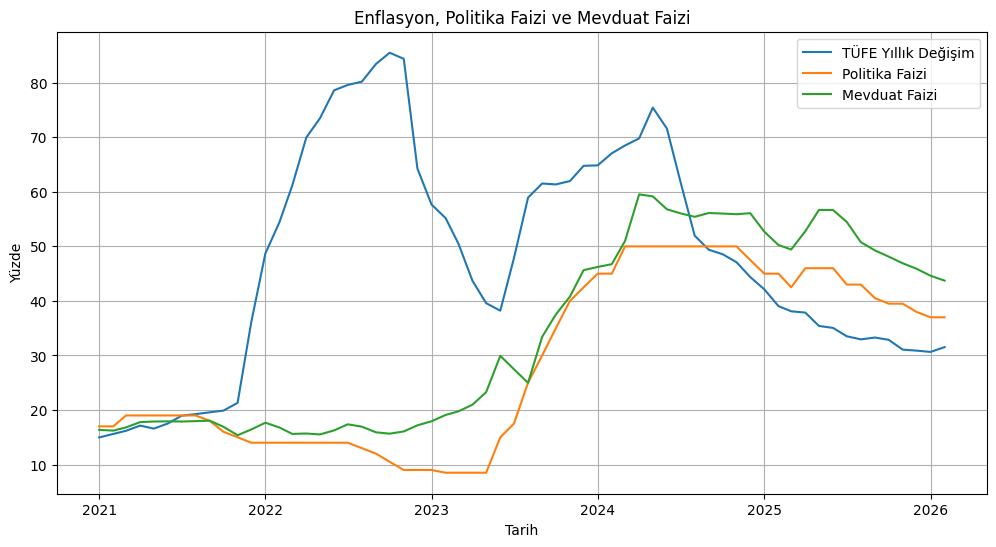

In [5]:
# Enflasyon - Politika Faizi - Mevduat Faizi

plt.figure(figsize=(12,6))
plt.plot(analiz["Tarih"], analiz["TÜFE_Yıllık_Değişim"], label="TÜFE Yıllık Değişim")
plt.plot(analiz["Tarih"], analiz["Politika_Faizi"], label="Politika Faizi")
plt.plot(analiz["Tarih"], analiz["Mevduat_Faizi"], label="Mevduat Faizi")

plt.title("Enflasyon, Politika Faizi ve Mevduat Faizi")
plt.xlabel("Tarih")
plt.ylabel("Yüzde")
plt.legend()
plt.grid(True)
plt.show()

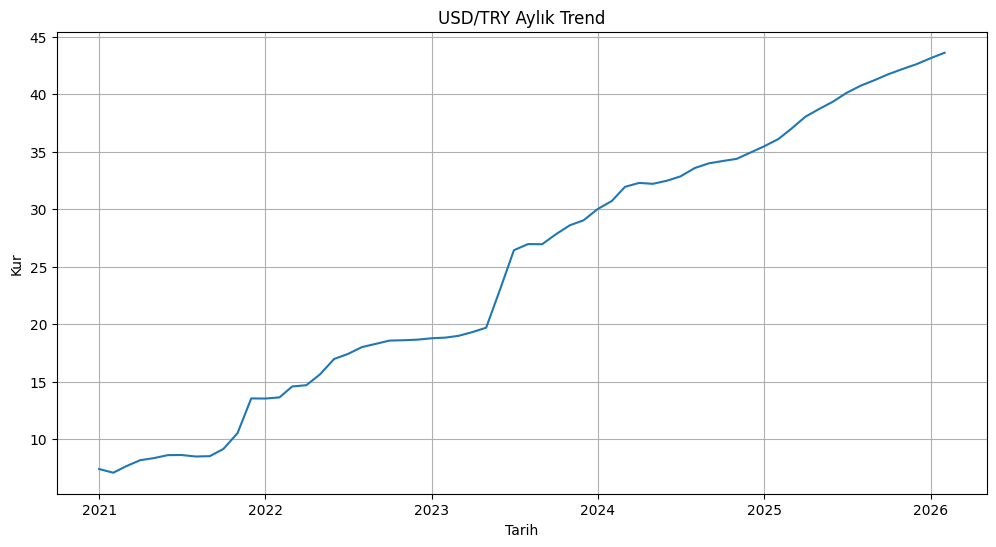

In [6]:
# USD/TRY trendi

plt.figure(figsize=(12,6))
plt.plot(analiz["Tarih"], analiz["USDTRY"])

plt.title("USD/TRY Aylık Trend")
plt.xlabel("Tarih")
plt.ylabel("Kur")
plt.grid(True)
plt.show()

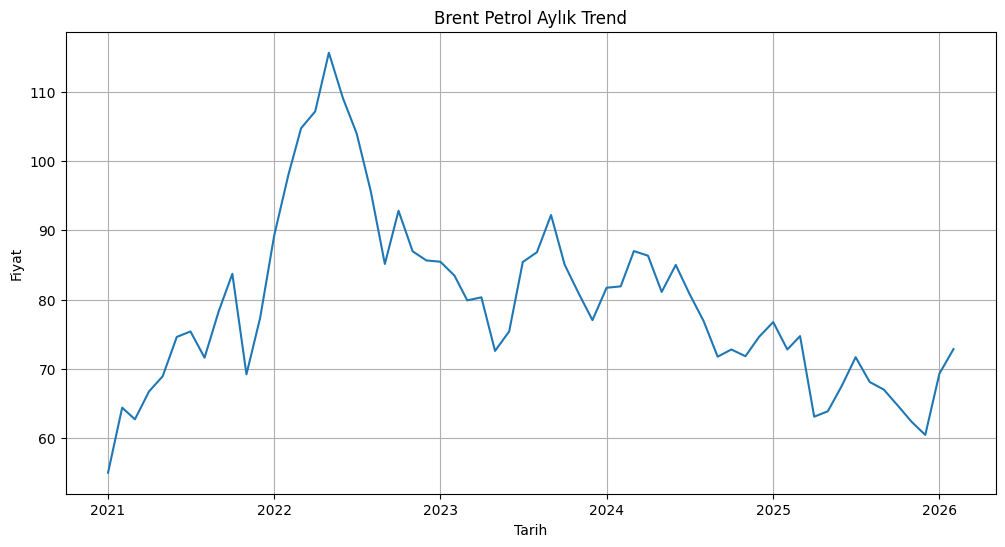

In [7]:
# Brent petrol trendi

plt.figure(figsize=(12,6))
plt.plot(analiz["Tarih"], analiz["Brent_Petrol"])

plt.title("Brent Petrol Aylık Trend")
plt.xlabel("Tarih")
plt.ylabel("Fiyat")
plt.grid(True)
plt.show()

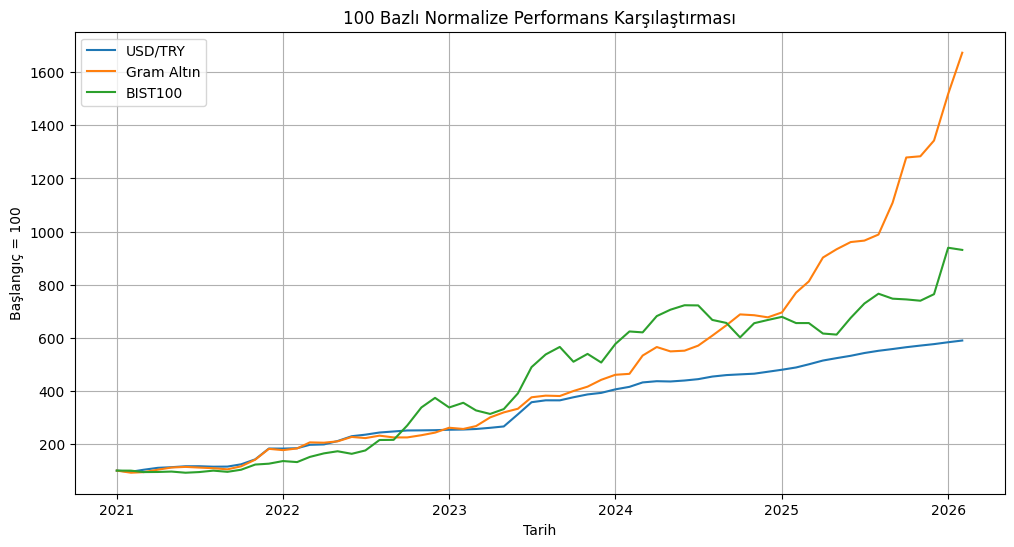

In [8]:
# 100 bazlı normalize performans / Başlangıç değeri 100 birim kabul edilmiştir.

analiz["USDTRY_100"] = (analiz["USDTRY"] / analiz["USDTRY"].iloc[0]) * 100
analiz["Gram_Altın_100"] = (analiz["Gram_Altın"] / analiz["Gram_Altın"].iloc[0]) * 100
analiz["BIST100_100"] = (analiz["BIST100"] / analiz["BIST100"].iloc[0]) * 100

plt.figure(figsize=(12,6))
plt.plot(analiz["Tarih"], analiz["USDTRY_100"], label="USD/TRY")
plt.plot(analiz["Tarih"], analiz["Gram_Altın_100"], label="Gram Altın")
plt.plot(analiz["Tarih"], analiz["BIST100_100"], label="BIST100")

plt.title("100 Bazlı Normalize Performans Karşılaştırması")
plt.xlabel("Tarih")
plt.ylabel("Başlangıç = 100")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Toplam değişim tablosu

toplam_degisim_genis = pd.DataFrame({
    "Varlık": [
        "USD/TRY",
        "Gram Altın",
        "BIST100",
        "BIST Gıda",
        "BIST Kimya",
        "BIST Ulaştırma",
        "Brent Petrol",
        "5Y Tahvil Faizi"
    ],
    "Başlangıç": [
        analiz["USDTRY"].iloc[0],
        analiz["Gram_Altın"].iloc[0],
        analiz["BIST100"].iloc[0],
        analiz["BIST_Gıda"].iloc[0],
        analiz["BIST_Kimya"].iloc[0],
        analiz["BIST_Ulaştırma"].iloc[0],
        analiz["Brent_Petrol"].iloc[0],
        analiz["Tahvil_5Y_Faizi"].iloc[0]
    ],
    "Bitiş": [
        analiz["USDTRY"].iloc[-1],
        analiz["Gram_Altın"].iloc[-1],
        analiz["BIST100"].iloc[-1],
        analiz["BIST_Gıda"].iloc[-1],
        analiz["BIST_Kimya"].iloc[-1],
        analiz["BIST_Ulaştırma"].iloc[-1],
        analiz["Brent_Petrol"].iloc[-1],
        analiz["Tahvil_5Y_Faizi"].iloc[-1]
    ]
})

toplam_degisim_genis["Toplam_Değişim_%"] = ((toplam_degisim_genis["Bitiş"] / toplam_degisim_genis["Başlangıç"]) - 1) * 100
toplam_degisim_genis["Toplam_Değişim_%"] = toplam_degisim_genis["Toplam_Değişim_%"].round(2)

toplam_degisim_genis

,Varlık,Başlangıç,Bitiş,Toplam_Değişim_%
0,USD/TRY,7.39,43.59,489.85
1,Gram Altın,449.12,7515.92,1573.48
2,BIST100,1473.45,13717.81,831.00
3,BIST Gıda,2126.55,14457.32,579.85
4,BIST Kimya,1920.05,14539.96,657.27
5,BIST Ulaştırma,1635.58,38111.92,2230.18
6,Brent Petrol,55.04,72.87,32.39
7,5Y Tahvil Faizi,12.93,30.98,139.60


In [10]:
# Gerçek reel getiri

analiz["Reel_Getiri"] = ((((1 + analiz["Mevduat_Faizi"]/100) / (1 + analiz["TÜFE_Yıllık_Değişim"]/100)) - 1) * 100).round(2)

analiz[["Tarih", "Mevduat_Faizi", "TÜFE_Yıllık_Değişim", "Reel_Getiri"]].head()

,Tarih,Mevduat_Faizi,TÜFE_Yıllık_Değişim,Reel_Getiri
0,2021-01-01,16.36,14.97,1.21
1,2021-02-01,16.22,15.61,0.53
2,2021-03-01,16.81,16.19,0.53
3,2021-04-01,17.78,17.14,0.55
4,2021-05-01,17.89,16.59,1.12


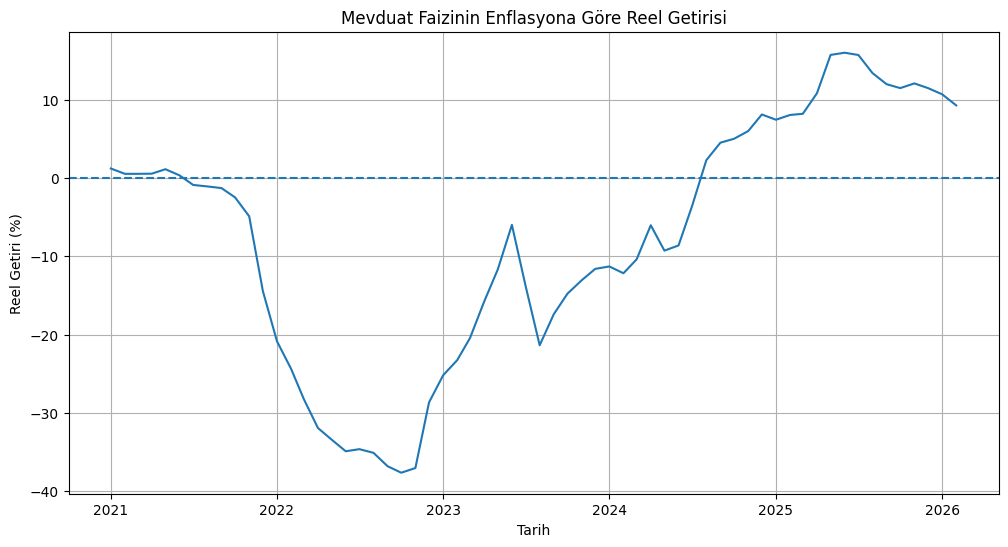

In [11]:
# Gerçek reel getiri grafiği

plt.figure(figsize=(12,6))
plt.plot(analiz["Tarih"], analiz["Reel_Getiri"])

plt.axhline(0, linestyle="--")
plt.title("Mevduat Faizinin Enflasyona Göre Reel Getirisi")
plt.xlabel("Tarih")
plt.ylabel("Reel Getiri (%)")
plt.grid(True)
plt.show()

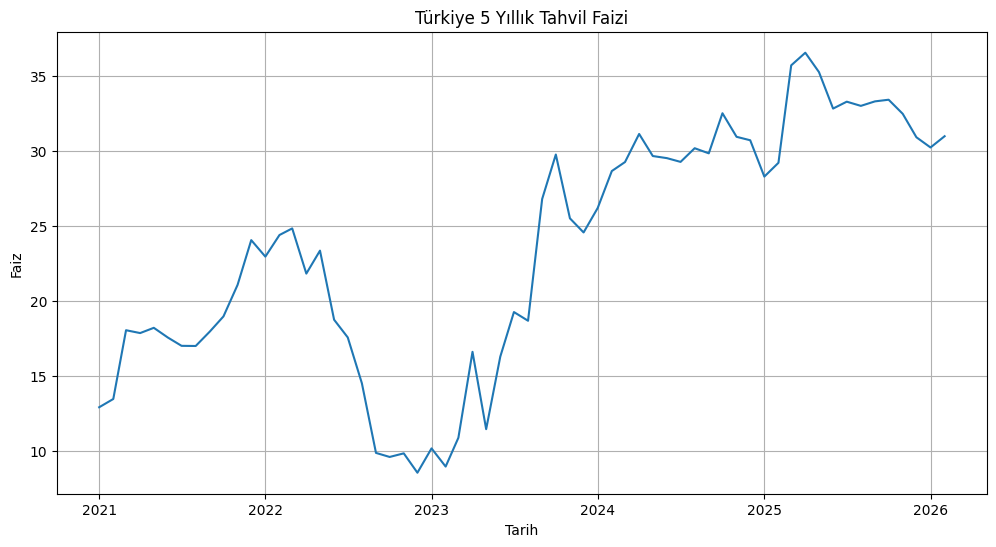

In [12]:
# 5 yıllık tahvil faizi trendi

plt.figure(figsize=(12,6))
plt.plot(analiz["Tarih"], analiz["Tahvil_5Y_Faizi"])

plt.title("Türkiye 5 Yıllık Tahvil Faizi")
plt.xlabel("Tarih")
plt.ylabel("Faiz")
plt.grid(True)
plt.show()

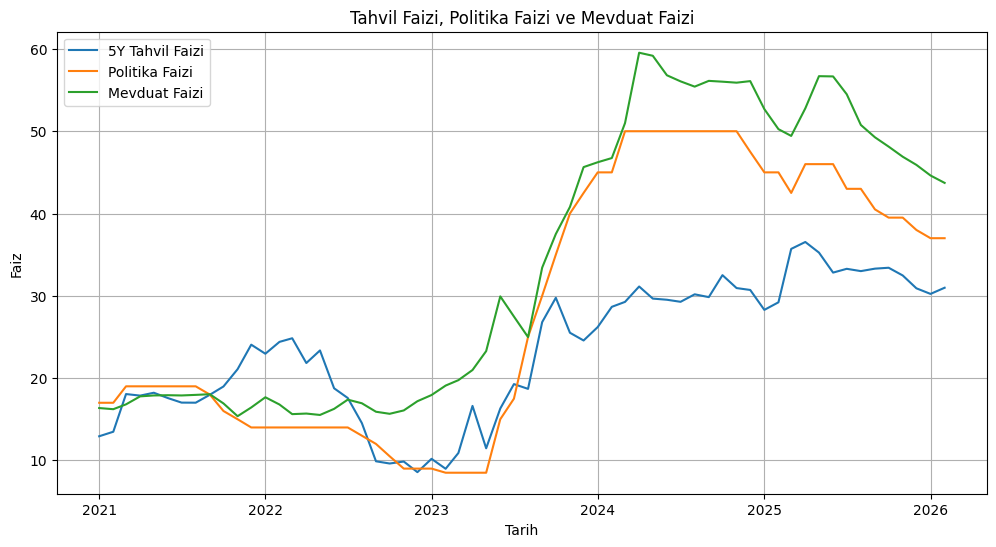

In [13]:
# Tahvil faizi - politika faizi - mevduat faizi

plt.figure(figsize=(12,6))
plt.plot(analiz["Tarih"], analiz["Tahvil_5Y_Faizi"], label="5Y Tahvil Faizi")
plt.plot(analiz["Tarih"], analiz["Politika_Faizi"], label="Politika Faizi")
plt.plot(analiz["Tarih"], analiz["Mevduat_Faizi"], label="Mevduat Faizi")

plt.title("Tahvil Faizi, Politika Faizi ve Mevduat Faizi")
plt.xlabel("Tarih")
plt.ylabel("Faiz")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Sektör endekslerini 100 bazlı normalize etme

analiz["BIST_Gıda_100"] = (analiz["BIST_Gıda"] / analiz["BIST_Gıda"].iloc[0]) * 100
analiz["BIST_Kimya_100"] = (analiz["BIST_Kimya"] / analiz["BIST_Kimya"].iloc[0]) * 100
analiz["BIST_Ulaştırma_100"] = (analiz["BIST_Ulaştırma"] / analiz["BIST_Ulaştırma"].iloc[0]) * 100

analiz[["Tarih", "BIST_Gıda_100", "BIST_Kimya_100", "BIST_Ulaştırma_100"]].head()

,Tarih,BIST_Gıda_100,BIST_Kimya_100,BIST_Ulaştırma_100
0,2021-01-01,100.000000,100.000000,100.000000
1,2021-02-01,94.277586,108.998724,112.821140
2,2021-03-01,92.581411,109.992969,106.991404
3,2021-04-01,95.136724,106.813885,103.216596
4,2021-05-01,91.439186,105.840473,113.346336


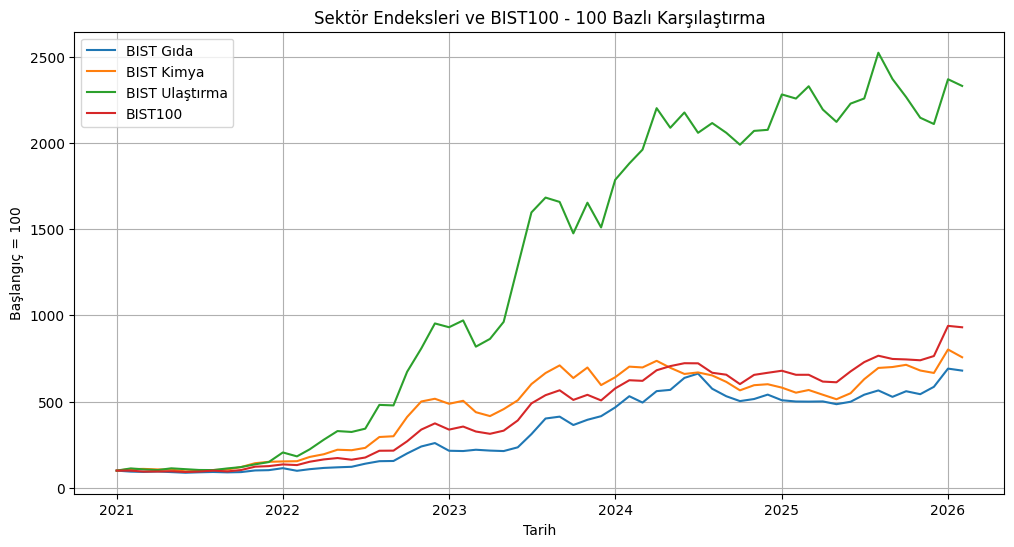

In [15]:
# Sektör endeksleri normalize performans karşılaştırması

plt.figure(figsize=(12,6))
plt.plot(analiz["Tarih"], analiz["BIST_Gıda_100"], label="BIST Gıda")
plt.plot(analiz["Tarih"], analiz["BIST_Kimya_100"], label="BIST Kimya")
plt.plot(analiz["Tarih"], analiz["BIST_Ulaştırma_100"], label="BIST Ulaştırma")
plt.plot(analiz["Tarih"], analiz["BIST100_100"], label="BIST100")

plt.title("Sektör Endeksleri ve BIST100 - 100 Bazlı Karşılaştırma")
plt.xlabel("Tarih")
plt.ylabel("Başlangıç = 100")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Aylık yüzde değişimler

analiz["USDTRY_Aylık_Değişim"] = analiz["USDTRY"].pct_change() * 100
analiz["Gram_Altın_Aylık_Değişim"] = analiz["Gram_Altın"].pct_change() * 100
analiz["BIST100_Aylık_Değişim"] = analiz["BIST100"].pct_change() * 100
analiz["Brent_Petrol_Aylık_Değişim"] = analiz["Brent_Petrol"].pct_change() * 100
analiz["BIST_Gıda_Aylık_Değişim"] = analiz["BIST_Gıda"].pct_change() * 100
analiz["BIST_Kimya_Aylık_Değişim"] = analiz["BIST_Kimya"].pct_change() * 100
analiz["BIST_Ulaştırma_Aylık_Değişim"] = analiz["BIST_Ulaştırma"].pct_change() * 100
analiz["Tahvil_5Y_Aylık_Değişim"] = analiz["Tahvil_5Y_Faizi"].pct_change() * 100

analiz.head()

,Tarih,TÜFE_Yıllık_Değişim,TÜFE_Aylık_Değişim,Politika_Faizi,Mevduat_Faizi,USDTRY,Gram_Altın,BIST100,Brent_Petrol,BIST_Gıda,...,BIST_Kimya_100,BIST_Ulaştırma_100,USDTRY_Aylık_Değişim,Gram_Altın_Aylık_Değişim,BIST100_Aylık_Değişim,Brent_Petrol_Aylık_Değişim,BIST_Gıda_Aylık_Değişim,BIST_Kimya_Aylık_Değişim,BIST_Ulaştırma_Aylık_Değişim,Tahvil_5Y_Aylık_Değişim
0,2021-01-01,14.97,1.68,17.0,16.36,7.39,449.12,1473.45,55.04,2126.55,...,100.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-02-01,15.61,0.91,17.0,16.22,7.07,413.65,1471.39,64.42,2004.86,...,108.998724,112.821140,-4.330176,-7.897667,-0.139808,17.042151,-5.722414,8.998724,12.821140,4.253674
2,2021-03-01,16.19,1.08,19.0,16.81,7.63,423.38,1391.73,62.74,1968.79,...,109.992969,106.991404,7.920792,2.352230,-5.413928,-2.607886,-1.799128,0.912162,-5.167237,33.976261
3,2021-04-01,17.14,1.68,19.0,17.78,8.16,464.33,1397.82,66.76,2023.13,...,106.813885,103.216596,6.946265,9.672162,0.437585,6.407396,2.760071,-2.890261,-3.528141,-1.052049
4,2021-05-01,16.59,0.89,19.0,17.89,8.34,501.26,1420.49,68.95,1944.50,...,105.840473,113.346336,2.205882,7.953395,1.621811,3.280407,-3.886552,-0.911316,9.814061,1.958590


In [17]:
# Korelasyon tablosu

korelasyon = analiz[[
    "USDTRY_Aylık_Değişim",
    "Gram_Altın_Aylık_Değişim",
    "BIST100_Aylık_Değişim",
    "Brent_Petrol_Aylık_Değişim",
    "BIST_Gıda_Aylık_Değişim",
    "BIST_Kimya_Aylık_Değişim",
    "BIST_Ulaştırma_Aylık_Değişim",
    "Tahvil_5Y_Aylık_Değişim"
]].corr().round(2)

korelasyon

,USDTRY_Aylık_Değişim,Gram_Altın_Aylık_Değişim,BIST100_Aylık_Değişim,Brent_Petrol_Aylık_Değişim,BIST_Gıda_Aylık_Değişim,BIST_Kimya_Aylık_Değişim,BIST_Ulaştırma_Aylık_Değişim,Tahvil_5Y_Aylık_Değişim
USDTRY_Aylık_Değişim,1.00,0.65,0.23,0.10,0.18,0.22,0.23,0.28
Gram_Altın_Aylık_Değişim,0.65,1.00,0.03,-0.06,-0.02,0.02,-0.03,0.22
BIST100_Aylık_Değişim,0.23,0.03,1.00,0.19,0.79,0.87,0.77,-0.10
Brent_Petrol_Aylık_Değişim,0.10,-0.06,0.19,1.00,0.15,0.20,0.31,0.23
BIST_Gıda_Aylık_Değişim,0.18,-0.02,0.79,0.15,1.00,0.65,0.56,-0.06
BIST_Kimya_Aylık_Değişim,0.22,0.02,0.87,0.20,0.65,1.00,0.75,-0.08
BIST_Ulaştırma_Aylık_Değişim,0.23,-0.03,0.77,0.31,0.56,0.75,1.00,-0.07
Tahvil_5Y_Aylık_Değişim,0.28,0.22,-0.10,0.23,-0.06,-0.08,-0.07,1.00


In [18]:
# Oynaklık tablosu

oynaklik = pd.DataFrame({
    "Varlık": [
        "USD/TRY",
        "Gram Altın",
        "BIST100",
        "Brent Petrol",
        "BIST Gıda",
        "BIST Kimya",
        "BIST Ulaştırma",
        "5Y Tahvil Faizi"
    ],
    "Aylık_Oynaklık": [
        analiz["USDTRY_Aylık_Değişim"].std(),
        analiz["Gram_Altın_Aylık_Değişim"].std(),
        analiz["BIST100_Aylık_Değişim"].std(),
        analiz["Brent_Petrol_Aylık_Değişim"].std(),
        analiz["BIST_Gıda_Aylık_Değişim"].std(),
        analiz["BIST_Kimya_Aylık_Değişim"].std(),
        analiz["BIST_Ulaştırma_Aylık_Değişim"].std(),
        analiz["Tahvil_5Y_Aylık_Değişim"].std()
    ]
})

oynaklik["Aylık_Oynaklık"] = oynaklik["Aylık_Oynaklık"].round(2)
oynaklik = oynaklik.sort_values("Aylık_Oynaklık", ascending=False).reset_index(drop=True)

oynaklik

,Varlık,Aylık_Oynaklık
0,5Y Tahvil Faizi,14.95
1,BIST Ulaştırma,12.44
2,BIST Kimya,9.80
3,BIST Gıda,9.71
4,BIST100,8.89
5,Brent Petrol,7.25
6,Gram Altın,6.38
7,USD/TRY,4.98


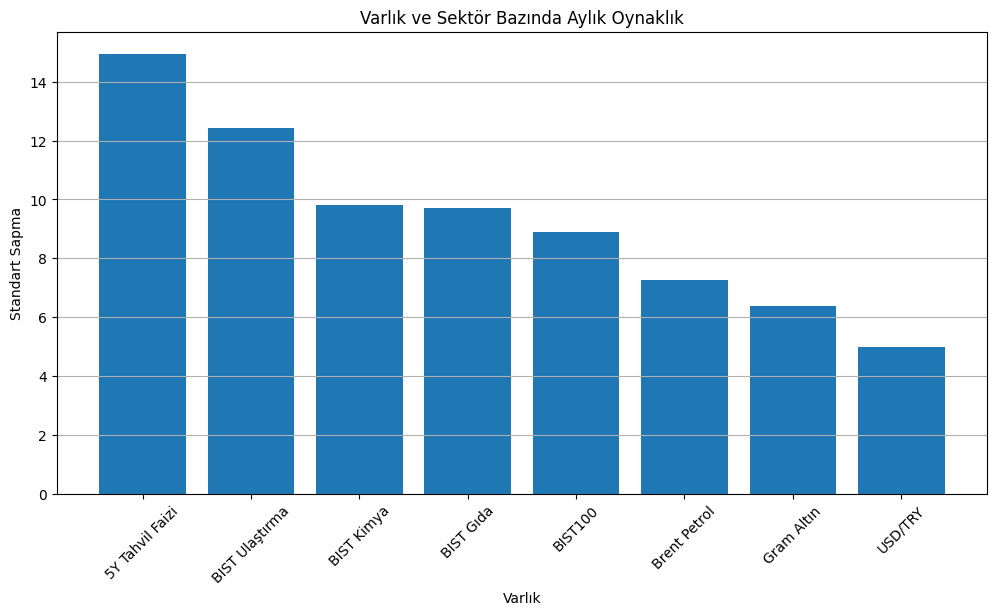

In [19]:
# Oynaklık grafiği

plt.figure(figsize=(12,6))
plt.bar(oynaklik["Varlık"], oynaklik["Aylık_Oynaklık"])

plt.title("Varlık ve Sektör Bazında Aylık Oynaklık")
plt.xlabel("Varlık")
plt.ylabel("Standart Sapma")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()

In [20]:
# Petrol artışının en yüksek olduğu aylar

petrol_soklari = analiz[[
    "Tarih",
    "Brent_Petrol_Aylık_Değişim",
    "BIST_Gıda_Aylık_Değişim",
    "BIST_Kimya_Aylık_Değişim",
    "BIST_Ulaştırma_Aylık_Değişim",
    "BIST100_Aylık_Değişim",
    "Gram_Altın_Aylık_Değişim",
    "USDTRY_Aylık_Değişim"
]].sort_values("Brent_Petrol_Aylık_Değişim", ascending=False).head(10)

petrol_soklari

,Tarih,Brent_Petrol_Aylık_Değişim,BIST_Gıda_Aylık_Değişim,BIST_Kimya_Aylık_Değişim,BIST_Ulaştırma_Aylık_Değişim,BIST100_Aylık_Değişim,Gram_Altın_Aylık_Değişim,USDTRY_Aylık_Değişim
1,2021-02-01,17.042151,-5.722414,8.998724,12.821140,-0.139808,-7.897667,-4.330176
12,2022-01-01,15.397544,11.164940,1.532825,37.303687,7.835168,-2.717677,-0.073910
60,2026-01-01,14.597454,18.016006,20.411117,12.308652,22.881192,13.047710,1.220944
30,2023-07-01,13.287362,32.574138,18.536625,24.234594,25.313807,12.964796,14.570685
11,2021-12-01,11.729019,1.704474,5.554544,9.678504,2.652447,28.934130,28.612167
13,2022-02-01,9.758010,-13.322377,0.841658,-11.059990,-2.845946,3.602007,0.739645
8,2021-09-01,9.325702,-2.402209,2.932192,9.292715,-4.461744,-3.945542,0.353774
21,2022-10-01,9.008692,28.071043,37.416480,40.819503,25.124922,0.017817,1.531729
5,2021-06-01,8.223350,-3.965544,-9.846028,-4.362765,-4.516047,2.144596,3.117506
16,2022-05-01,7.896211,3.058046,13.348698,17.870117,4.794800,2.503773,6.403270


In [21]:
# Tahvil faizinin en hızlı arttığı aylar

tahvil_soklari = analiz[[
    "Tarih",
    "Tahvil_5Y_Aylık_Değişim",
    "BIST100_Aylık_Değişim",
    "BIST_Gıda_Aylık_Değişim",
    "BIST_Kimya_Aylık_Değişim",
    "BIST_Ulaştırma_Aylık_Değişim",
    "Gram_Altın_Aylık_Değişim",
    "USDTRY_Aylık_Değişim"
]].sort_values("Tahvil_5Y_Aylık_Değişim", ascending=False).head(10)

tahvil_soklari

,Tarih,Tahvil_5Y_Aylık_Değişim,BIST100_Aylık_Değişim,BIST_Gıda_Aylık_Değişim,BIST_Kimya_Aylık_Değişim,BIST_Ulaştırma_Aylık_Değişim,Gram_Altın_Aylık_Değişim,USDTRY_Aylık_Değişim
27,2023-04-01,52.477064,-4.051586,-2.221243,-5.142516,5.505690,12.219717,1.739589
32,2023-09-01,43.392188,5.266654,2.700904,6.649883,-1.499300,-0.371598,-0.037106
29,2023-06-01,42.109852,17.847679,10.162937,11.207778,33.551357,4.292998,17.174797
2,2021-03-01,33.976261,-5.413928,-1.799128,0.912162,-5.167237,2.352230,7.920792
50,2025-03-01,22.218418,0.007869,-0.134026,2.802846,3.161295,5.480256,2.438349
26,2023-03-01,21.380846,-8.103366,3.501269,-13.083965,-15.672230,4.189566,0.797024
24,2023-01-01,18.903151,-9.667717,-17.191083,-5.642449,-2.312211,7.549884,0.643777
30,2023-07-01,18.220859,25.313807,32.574138,18.536625,24.234594,12.964796,14.570685
11,2021-12-01,14.136622,2.652447,1.704474,5.554544,9.678504,28.934130,28.612167
10,2021-11-01,11.064278,18.896350,10.464123,18.763596,13.174002,21.611307,15.098468


In [22]:
# Enflasyon şoku aylarını bulma

enflasyon_sok_aylari = analiz.nlargest(6, "TÜFE_Aylık_Değişim")["Tarih"]
enflasyon_sok_aylari

,Tarih
11,2021-12-01
12,2022-01-01
30,2023-07-01
31,2023-08-01
15,2022-04-01
36,2024-01-01


In [23]:
# Petrol şoku aylarını bulma

petrol_sok_aylari = analiz.nlargest(6, "Brent_Petrol_Aylık_Değişim")["Tarih"]
petrol_sok_aylari

,Tarih
1,2021-02-01
12,2022-01-01
60,2026-01-01
30,2023-07-01
11,2021-12-01
13,2022-02-01


In [24]:
# Tahvil şoku aylarını bulma

tahvil_sok_aylari = analiz.nlargest(6, "Tahvil_5Y_Aylık_Değişim")["Tarih"]
tahvil_sok_aylari

,Tarih
27,2023-04-01
32,2023-09-01
29,2023-06-01
2,2021-03-01
50,2025-03-01
26,2023-03-01


In [25]:
# Şok dönemlerinde ortalama değişimi hesaplayan fonksiyon

def sok_donemi_ortalama_degisim(df, sok_aylari, kolonlar):
    filtreli = df[df["Tarih"].isin(sok_aylari)][kolonlar]
    sonuc = filtreli.mean().sort_values(ascending=False).reset_index()
    sonuc.columns = ["Varlık", "Ortalama_Aylık_Değişim"]
    return sonuc

In [26]:
# Petrol şokunda diğer varlıkların/sektörlerin ortalama değişimi

petrol_sok_grafik = sok_donemi_ortalama_degisim(
    analiz,
    petrol_sok_aylari,
    [
        "USDTRY_Aylık_Değişim",
        "Gram_Altın_Aylık_Değişim",
        "BIST100_Aylık_Değişim",
        "BIST_Gıda_Aylık_Değişim",
        "BIST_Kimya_Aylık_Değişim",
        "BIST_Ulaştırma_Aylık_Değişim",
        "Tahvil_5Y_Aylık_Değişim"
    ]
)

petrol_sok_grafik

,Varlık,Ortalama_Aylık_Değişim
0,BIST_Ulaştırma_Aylık_Değişim,14.214431
1,BIST_Kimya_Aylık_Değişim,9.312582
2,BIST100_Aylık_Değişim,9.282810
3,Gram_Altın_Aylık_Değişim,7.988883
4,BIST_Gıda_Aylık_Değişim,7.402461
5,USDTRY_Aylık_Değişim,6.789893
6,Tahvil_5Y_Aylık_Değişim,6.018516


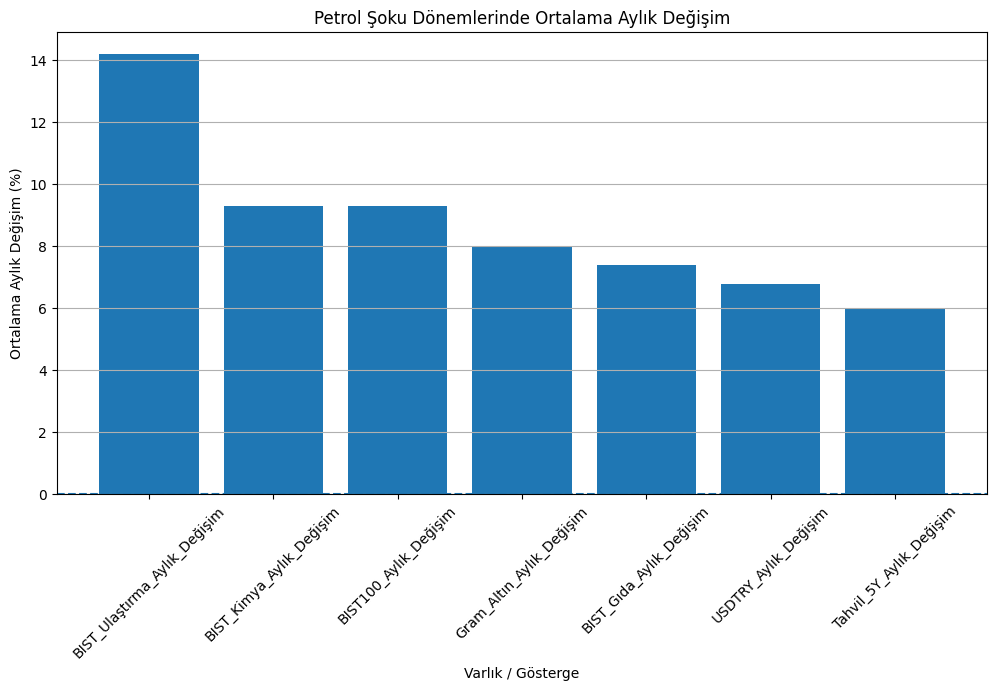

In [27]:
# Petrol şoku grafiği

plt.figure(figsize=(12,6))
plt.bar(petrol_sok_grafik["Varlık"], petrol_sok_grafik["Ortalama_Aylık_Değişim"])

plt.axhline(0, linestyle="--")
plt.title("Petrol Şoku Dönemlerinde Ortalama Aylık Değişim")
plt.xlabel("Varlık / Gösterge")
plt.ylabel("Ortalama Aylık Değişim (%)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()

In [28]:
# Tahvil şokunda diğer varlıkların/sektörlerin ortalama değişimi

tahvil_sok_grafik = sok_donemi_ortalama_degisim(
    analiz,
    tahvil_sok_aylari,
    [
        "USDTRY_Aylık_Değişim",
        "Gram_Altın_Aylık_Değişim",
        "BIST100_Aylık_Değişim",
        "BIST_Gıda_Aylık_Değişim",
        "BIST_Kimya_Aylık_Değişim",
        "BIST_Ulaştırma_Aylık_Değişim",
        "Brent_Petrol_Aylık_Değişim"
    ]
)

tahvil_sok_grafik

,Varlık,Ortalama_Aylık_Değişim
0,USDTRY_Aylık_Değişim,5.005574
1,Gram_Altın_Aylık_Değişim,4.693862
2,BIST_Ulaştırma_Aylık_Değişim,3.313263
3,BIST_Gıda_Aylık_Değişim,2.035119
4,Brent_Petrol_Aylık_Değişim,1.063767
5,BIST100_Aylık_Değişim,0.925554
6,BIST_Kimya_Aylık_Değişim,0.557698


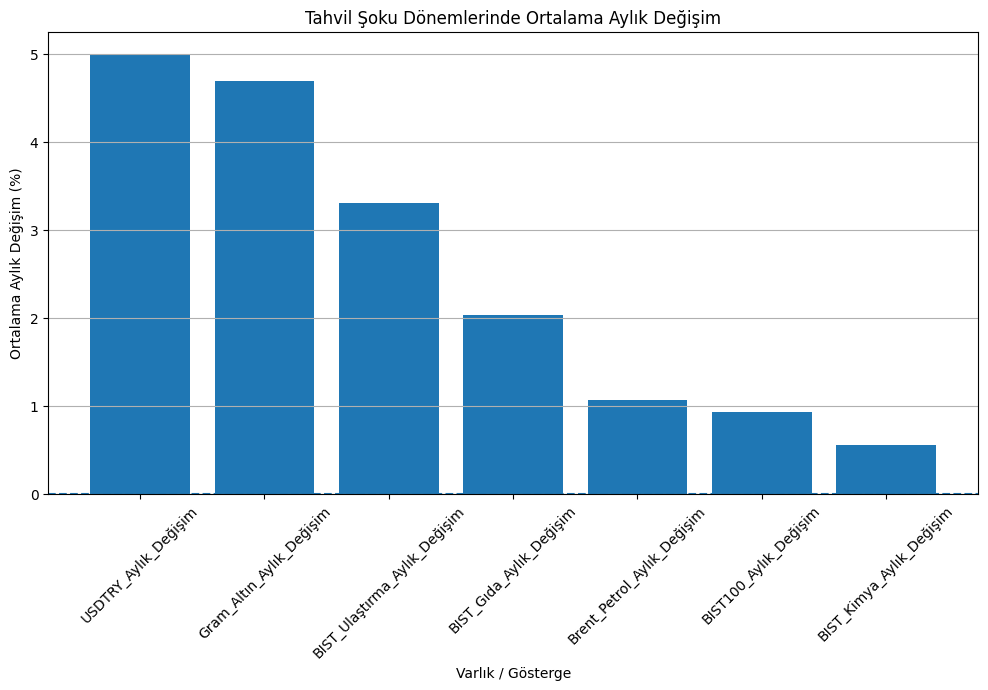

In [29]:
# Tahvil şoku grafiği

plt.figure(figsize=(12,6))
plt.bar(tahvil_sok_grafik["Varlık"], tahvil_sok_grafik["Ortalama_Aylık_Değişim"])

plt.axhline(0, linestyle="--")
plt.title("Tahvil Şoku Dönemlerinde Ortalama Aylık Değişim")
plt.xlabel("Varlık / Gösterge")
plt.ylabel("Ortalama Aylık Değişim (%)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()

In [30]:
# Enflasyon şokunda diğer varlıkların/sektörlerin ortalama değişimi

enflasyon_sok_grafik = sok_donemi_ortalama_degisim(
    analiz,
    enflasyon_sok_aylari,
    [
        "USDTRY_Aylık_Değişim",
        "Gram_Altın_Aylık_Değişim",
        "BIST100_Aylık_Değişim",
        "BIST_Gıda_Aylık_Değişim",
        "BIST_Kimya_Aylık_Değişim",
        "BIST_Ulaştırma_Aylık_Değişim",
        "Tahvil_5Y_Aylık_Değişim"
    ]
)

enflasyon_sok_grafik

,Varlık,Ortalama_Aylık_Değişim
0,BIST_Ulaştırma_Aylık_Değişim,19.978815
1,BIST_Gıda_Aylık_Değişim,15.570650
2,BIST100_Aylık_Değişim,11.347915
3,BIST_Kimya_Aylık_Değişim,8.773210
4,USDTRY_Aylık_Değişim,8.207826
5,Gram_Altın_Aylık_Değişim,7.420745
6,Tahvil_5Y_Aylık_Değişim,3.215379


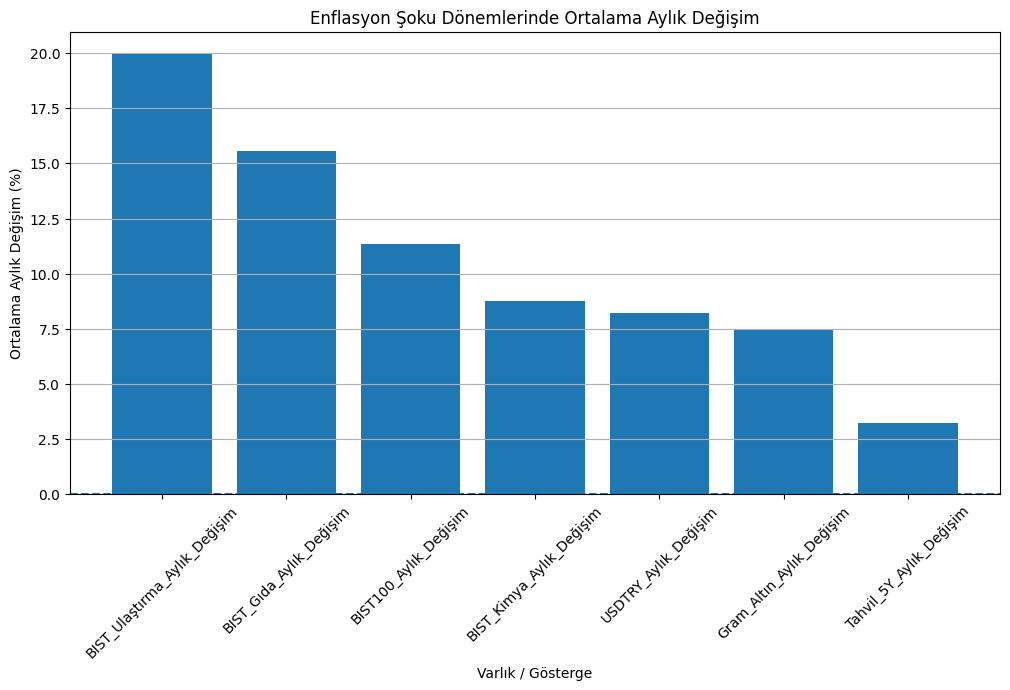

In [31]:
# Enflasyon şoku grafiği

plt.figure(figsize=(12,6))
plt.bar(enflasyon_sok_grafik["Varlık"], enflasyon_sok_grafik["Ortalama_Aylık_Değişim"])

plt.axhline(0, linestyle="--")
plt.title("Enflasyon Şoku Dönemlerinde Ortalama Aylık Değişim")
plt.xlabel("Varlık / Gösterge")
plt.ylabel("Ortalama Aylık Değişim (%)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()

In [32]:
# Reel getiri karşılaştırması için yıllık nominal değişimler

analiz["USDTRY_Yillik_Getiri"] = analiz["USDTRY"].pct_change(12) * 100
analiz["Gram_Altin_Yillik_Getiri"] = analiz["Gram_Altın"].pct_change(12) * 100
analiz["BIST100_Yillik_Getiri"] = analiz["BIST100"].pct_change(12) * 100

# Mevduat için yaklaşık reel getiri hesabı
# Aylık mevduat faizi yıllık oran olarak geldiği için doğrudan TÜFE yıllık değişim ile karşılaştırıyoruz
analiz["Mevduat_Reel_Getiri"] = analiz["Mevduat_Faizi"] - analiz["TÜFE_Yıllık_Değişim"]

# Diğer araçlar için reel getiri
analiz["USDTRY_Reel_Getiri"] = analiz["USDTRY_Yillik_Getiri"] - analiz["TÜFE_Yıllık_Değişim"]
analiz["Gram_Altin_Reel_Getiri"] = analiz["Gram_Altin_Yillik_Getiri"] - analiz["TÜFE_Yıllık_Değişim"]
analiz["BIST100_Reel_Getiri"] = analiz["BIST100_Yillik_Getiri"] - analiz["TÜFE_Yıllık_Değişim"]

# Kontrol
analiz[[
    "Tarih",
    "Mevduat_Reel_Getiri",
    "USDTRY_Reel_Getiri",
    "Gram_Altin_Reel_Getiri",
    "BIST100_Reel_Getiri"
]].tail()

,Tarih,Mevduat_Reel_Getiri,USDTRY_Reel_Getiri,Gram_Altin_Reel_Getiri,BIST100_Reel_Getiri
57,2025-10-01,15.26,-10.745329,52.982164,-9.092151
58,2025-11-01,15.83,-8.310978,56.291907,-18.153506
59,2025-12-01,15.02,-8.855616,67.420797,-16.333759
60,2026-01-01,13.97,-9.076396,87.556637,7.672315
61,2026-02-01,12.19,-10.748620,85.769742,10.495134


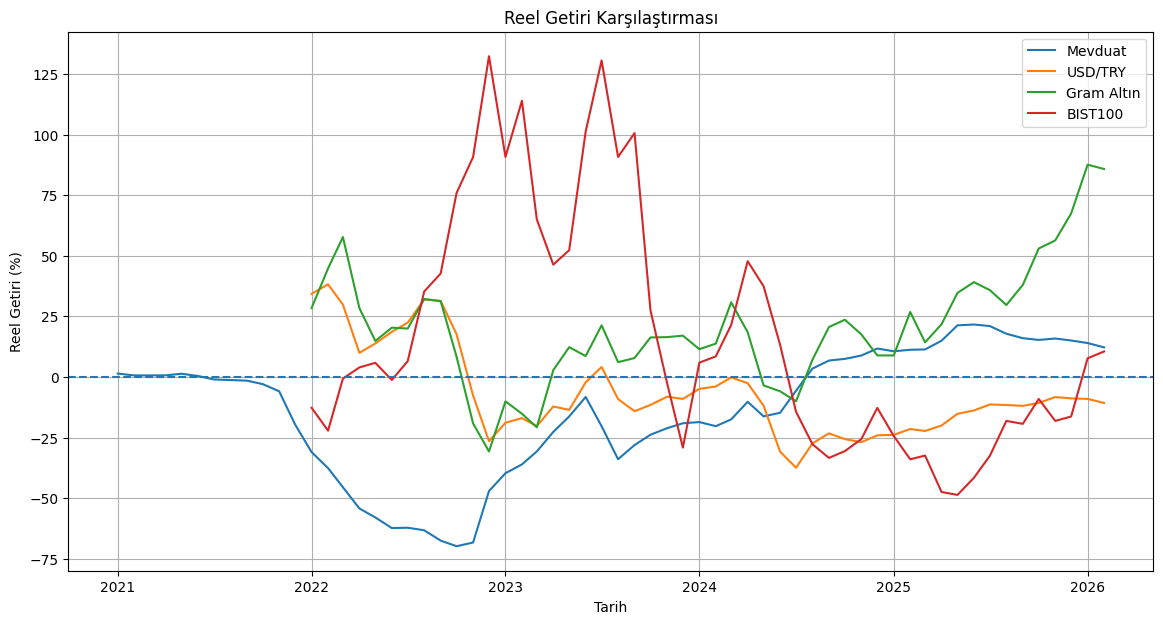

In [34]:
import matplotlib.pyplot as plt

# Reel getiri karşılaştırması grafiği

plt.figure(figsize=(14,7))

plt.plot(analiz["Tarih"], analiz["Mevduat_Reel_Getiri"], label="Mevduat")
plt.plot(analiz["Tarih"], analiz["USDTRY_Reel_Getiri"], label="USD/TRY")
plt.plot(analiz["Tarih"], analiz["Gram_Altin_Reel_Getiri"], label="Gram Altın")
plt.plot(analiz["Tarih"], analiz["BIST100_Reel_Getiri"], label="BIST100")

plt.axhline(0, linestyle="--")
plt.title("Reel Getiri Karşılaştırması")
plt.xlabel("Tarih")
plt.ylabel("Reel Getiri (%)")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
analiz.to_csv("Analiz_Veri_Seti_Analiz_Guncel.csv", index=False, encoding="utf-8-sig", sep=";")